# Copy Number Correction, Raw Data

June 6, 2024

## Goal:
Apply the copy number correction to the raw data.

**Procedure:**
For each gene:
1. Retrieve replication timing
2. H from config, determine proportion of cells that have replicated for each timepoint.
3. Correct copy number based on this proportion.
4. Repeat 1-3 for all genes
5. Normalize each sample to equal counts.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [219]:
from src.geneset import get_deconvolved_geneset
from src.delta_config import load_yl_delta_config
from src.config import read_yl_vst_data_rep

ge_data = read_yl_vst_data_rep(1)
genes = get_deconvolved_geneset()
gene = genes.loc['YCR073C']


In [214]:
from src.CopyNumberCorrection import copy_number_correct

In [225]:
from src.timer import Timer
from src.helpers import calcH_config

repl_profile = pd.read_csv('datasets/computed_mnase/'\
    'deconvolved_all_chr_replication_profile_delta_model.csv')
repl_profile = repl_profile.set_index(['chr', 'start'])

config = load_yl_delta_config(1)
H, Hpos = calcH_config(config)
    
timer = Timer()
i = 0
corrected_gene_expression = ge_data.copy()

for orf_name, gene in genes.iterrows():
    
    if i % 1000 == 0:
        timer.print_time(f"{i}/{len(genes)}")

    gene_expression = ge_data.loc[gene.name]

    corrected_data = copy_number_correct(H, gene, gene_expression, 
        repl_profile, genes)
    corrected_gene_expression.loc[orf_name] = corrected_data

    i += 1

0/5578 - 00:00:00.002
1000/5578 - 00:00:00.679
2000/5578 - 00:00:01.332
3000/5578 - 00:00:01.994
4000/5578 - 00:00:02.692
5000/5578 - 00:00:03.361


In [245]:
total_counts = 50000

normalized_corrected_ge = corrected_gene_expression / \
    corrected_gene_expression.sum(axis=0).values.reshape((1, -1)) * total_counts

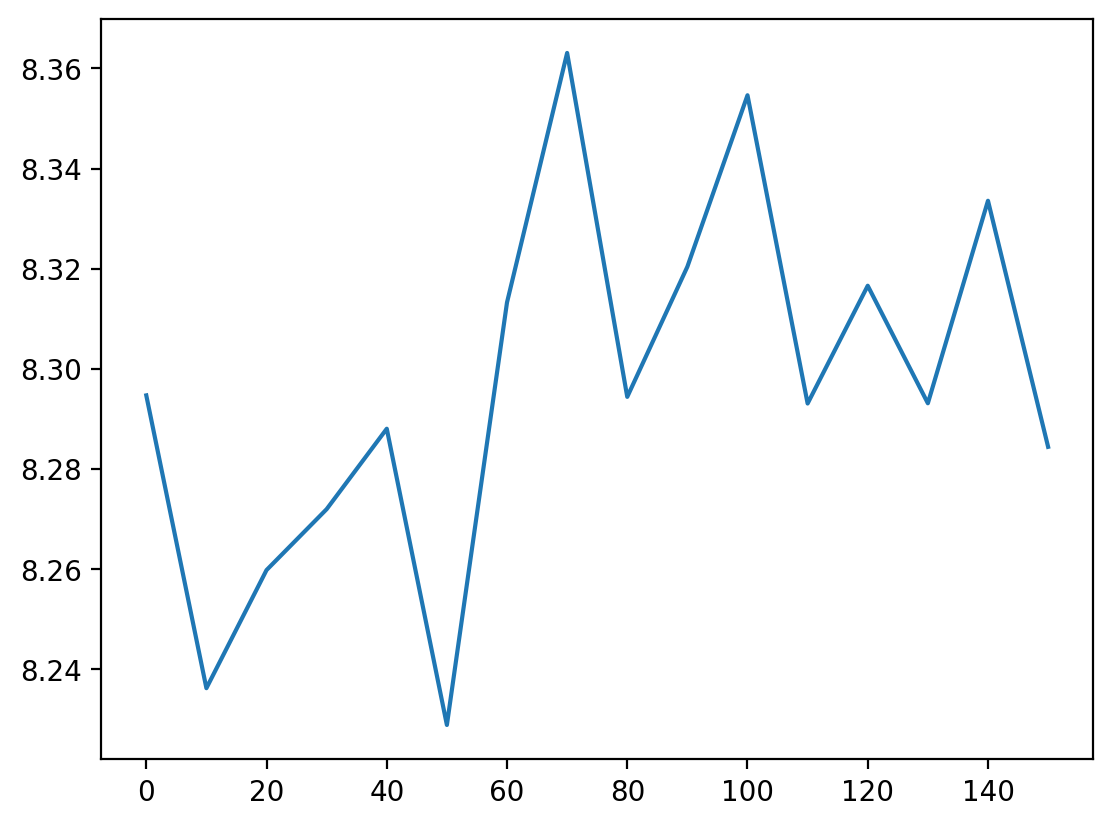

In [249]:
plt.plot(normalized_corrected_ge.iloc[100])

In [218]:
# Corrected data is going to introduce cyclicity in the expression
# Genes that appear to be stable are now going to appear to cycle...

# Need some justification that this procedure is going to be valid.
# Also will need to normalize all read counts for all genes. Perhaps
# this will normalize out the read counts for all genes...
